# NB02 — Data Preparation & Feature Engineering

**Obiettivo del notebook.** Trasformare i dati grezzi in una **base modellabile** pulita e
documentata, costruendo il target e un insieme di feature giustificate dal dominio.

1. Ricostruzione della base assicurato-anno (join esposizione ↔ sinistri)
2. Decisioni di pulizia (anomalie individuate in NB01), tutte tracciate
3. Costruzione del target: frequenza, severity, burning cost (+ versione *capped*)
4. Feature engineering:
   - anagrafiche e di polizza
   - struttura del nucleo 
   - dimensione/azienda
5. Controllo del **data leakage**
6. Split temporale (train uy 1–2, test uy 3) e stabilità del target
7. Salvataggio della base modellabile e del dizionario delle feature


## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')

DATA_PATH = '../data/dataset_esercizio_pricing.xlsx'
OUT_DIR = '../data/processed'
REP_DIR = '../reports'
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(REP_DIR, exist_ok=True)

## 1. Ricostruzione della base assicurato-anno

Carico le due tab, aggrego i sinistri per id_assicurato e li unisco
all'esposizione. Il risultato finale è **una riga per assicurato per anno**.

In [2]:
esp = pd.read_excel(DATA_PATH, 'esposizione')
sin = pd.read_excel(DATA_PATH, 'sinistri')
print('esposizione:', esp.shape, '| sinistri:', sin.shape)

# Mappo l'anno (uy) sui sinistri: serve per il capping su train e per i controlli
sin = sin.merge(esp[['id_assicurato', 'uy']], on='id_assicurato', how='left')
n_orfani = sin['uy'].isna().sum()
print(f'Sinistri orfani (senza assicurato): {n_orfani} ')

esposizione: (79000, 16) | sinistri: (40192, 5)
Sinistri orfani (senza assicurato): 52 


## 2. Decisioni di pulizia

Le anomalie sono quelle individuate in NB01. Scelte e motivazioni:

| Anomalia | N | Decisione | Motivazione |
|---|---|---|---|
| esposizione = 0 | 36 | **escludo** | burning cost = costo/esposizione non definito; nessun anno-uomo a rischio |
| esposizione > 1 (=1.01) | 8 | **cap a 1.0** | arrotondamento; l'esposizione annua non può superare 1 |
| importo < 0 | 0 | — | assenti |
| importo = 0 | 427 | **mantengo** | prestazioni reali a costo nullo: eventi validi (contano in frequenza, 0 in costo) |
| sinistri orfani | 52 | **escludo** | non agganciano alcun assicurato-anno (già esclusi dal join) |
| grandi sinistri (coda) | — | **versione *capped*** a p99.5 (calcolata su train) | stabilizza la severity; pratica attuariale (large-loss capping) |

In [3]:
# Cap esposizione a 1.0 e rimozione esposizione = 0
esp['esposizione'] = esp['esposizione'].clip(upper=1.0)
n_zero_exp = (esp['esposizione'] == 0).sum()
esp = esp[esp['esposizione'] > 0].copy()
print(f'Rimosse {n_zero_exp} righe con esposizione = 0 -> esposizione: {esp.shape}')

# Soglia di capping dei grandi sinistri stimata SOLO sul train (uy 1-2) per evitare leakage
CAP_Q = 0.995
cap_threshold = sin.loc[sin['uy'].isin([1, 2]), 'importo'].quantile(CAP_Q)
print(f'Soglia capping (p{CAP_Q:.1%} su train): {cap_threshold:,.1f}')
sin['importo_capped'] = sin['importo'].clip(upper=cap_threshold)
print('Quota costo tagliata dal capping (train+test): '
      f"{1 - sin['importo_capped'].sum()/sin['importo'].sum():.2%}")

Rimosse 36 righe con esposizione = 0 -> esposizione: (78964, 16)
Soglia capping (p99.5% su train): 560.0
Quota costo tagliata dal capping (train+test): 1.32%


## 3. Costruzione del target

$$\text{Frequenza}=\frac{n.\ sinistri}{esposizione},\quad
\text{Severity}=\frac{costo}{n.\ sinistri},\quad
\text{Burning cost}=\frac{costo}{esposizione}=Frequenza\times Severity$$

In [4]:
agg = (sin.groupby('id_assicurato')
          .agg(n_sinistri=('id_sinistro', 'size'),
               costo_totale=('importo', 'sum'),
               costo_capped=('importo_capped', 'sum')))

base = esp.merge(agg, on='id_assicurato', how='left')
for c in ['n_sinistri', 'costo_totale', 'costo_capped']:
    base[c] = base[c].fillna(0)

# Target e componenti
base['has_claim']    = (base['n_sinistri'] > 0).astype(int)
base['frequenza']    = base['n_sinistri'] / base['esposizione']
base['severity']     = np.where(base['n_sinistri'] > 0, base['costo_totale'] / base['n_sinistri'], np.nan)
base['burning_cost'] = base['costo_totale'] / base['esposizione']
base['burning_cost_capped'] = base['costo_capped'] / base['esposizione']

print('Base modellabile:', base.shape)
print('Sinistri attribuiti:', int(base['n_sinistri'].sum()), '| zero-claim:',
      f"{(base['has_claim']==0).mean():.1%}")
base[['esposizione' , 'n_sinistri' , 'costo_totale','frequenza','severity','burning_cost']].describe().round(2) 

Base modellabile: (78964, 24)
Sinistri attribuiti: 40140 | zero-claim: 75.7%


,esposizione,n_sinistri,costo_totale,frequenza,severity,burning_cost
count,78964.00,78964.00,78964.00,78964.00,19225.00,78964.00
mean,0.95,0.51,46.80,0.53,89.77,48.52
std,0.16,1.27,140.26,1.33,73.70,148.81
min,0.01,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,58.42,0.00
50%,1.00,0.00,0.00,0.00,76.50,0.00
75%,1.00,0.00,0.00,0.00,100.00,0.00
max,1.00,29.00,4209.51,31.25,2570.80,5649.23


## 4. Feature engineering

### 4.1 Anagrafiche e di polizza
Variabili note all'**inception** della copertura (quindi disponibili per il pricing, non leaky).

In [5]:
# Fasce di eta (cattura non linearita')
base['fascia_eta'] = pd.cut(base['eta'], [-1, 17, 30, 45, 60, 75, 100],
                            labels=['0-17', '18-30', '31-45', '46-60', '61-75', '75+'])
# composizione_nucleo: dichiarata, ordinale (8+ -> 8)
base['composizione_num'] = pd.to_numeric(
    base['composizione_nucleo'].astype(str).str.replace('+', '', regex=False), errors='coerce')
print('fascia_eta:'); print(base['fascia_eta'].value_counts().sort_index().to_string())
print('\ncomposizione_num range:', base['composizione_num'].min(), '-', base['composizione_num'].max())

fascia_eta:
fascia_eta
0-17     20394
18-30    10353
31-45    26159
46-60    19022
61-75     2775
75+        261

composizione_num range: 1 - 8


### 4.2 Struttura del nucleo
Composizione del nucleo assicurato **in ciascun anno**. Sono attributi noti all'inception
(chi è assicurato nel nucleo), quindi non introducono leakage.

In [6]:
# Calcolo su 'esp' (popolazione esposta) a livello (id_nucleo, uy)
esp['_is_figli'] = (esp['legame_familiare'] == 'FIGLI').astype(int)
g = esp.groupby(['id_nucleo', 'uy'])
nucleo_feat = pd.DataFrame({
    'n_assicurati_nucleo': g.size(),
    'eta_media_nucleo'   : g['eta'].mean(),
    'eta_min_nucleo'     : g['eta'].min(),
    'eta_max_nucleo'     : g['eta'].max(),
    'n_figli_nucleo'     : g['_is_figli'].sum(),
}).reset_index()
# eta del caponucleo (se presente nel nucleo-anno)
capo = (esp[esp['legame_familiare'] == 'CAPONUCLEO']
        .groupby(['id_nucleo', 'uy'])['eta'].first().rename('eta_caponucleo').reset_index())
nucleo_feat = nucleo_feat.merge(capo, on=['id_nucleo', 'uy'], how='left')
nucleo_feat['presenza_figli']   = (nucleo_feat['n_figli_nucleo'] > 0).astype(int)
nucleo_feat['presenza_anziani'] = (nucleo_feat['eta_max_nucleo'] >= 75).astype(int)

base = base.merge(nucleo_feat, on=['id_nucleo', 'uy'], how='left')
print('Feature nucleo aggiunte:', [c for c in nucleo_feat.columns if c not in ['id_nucleo','uy']])
print('eta_caponucleo mancante (nuclei senza riga caponucleo):',
      base['eta_caponucleo'].isna().sum())

Feature nucleo aggiunte: ['n_assicurati_nucleo', 'eta_media_nucleo', 'eta_min_nucleo', 'eta_max_nucleo', 'n_figli_nucleo', 'eta_caponucleo', 'presenza_figli', 'presenza_anziani']
eta_caponucleo mancante (nuclei senza riga caponucleo): 1


### 4.3 Dimensione dell'azienda

In [7]:
az_size = esp.groupby(['id_azienda', 'uy']).size().rename('dimensione_azienda').reset_index()
base = base.merge(az_size, on=['id_azienda', 'uy'], how='left')
base['log_dim_azienda'] = np.log1p(base['dimensione_azienda'])
print(base['dimensione_azienda'].describe().round(1).to_string())

count    78964.0
mean       984.0
std        819.7
min          1.0
25%        212.0
50%        956.0
75%       1356.0
max       2839.0


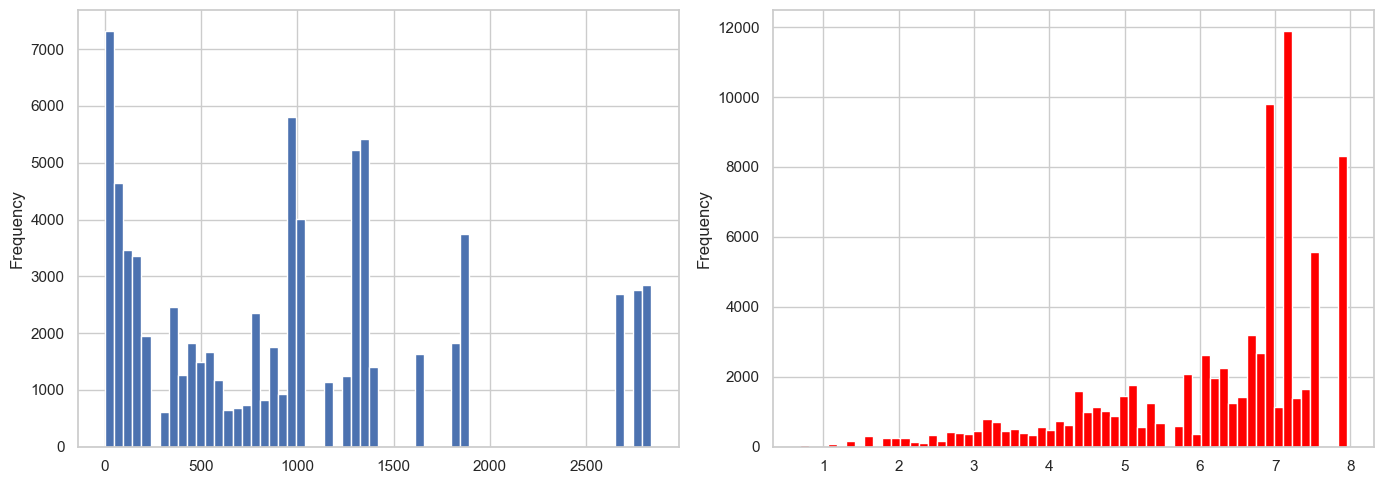

In [8]:
fig, ax =plt.subplots(1,2,figsize=(14,5))
base['dimensione_azienda'].plot.hist(bins=(60),ax=ax[0],edgecolor=('white'))
base['log_dim_azienda'].plot.hist(bins=60,ax=ax[1],edgecolor=('white'),color='red')

plt.tight_layout();plt.show()

## 5. Controllo del data leakage

Variabili **escluse** dai predittori perché non disponibili al momento del pricing
(sono *output* del periodo di copertura, non caratteristiche dell'assicurato all'inception):

| Variabile | Perché è leakage |
|---|---|
| `convenzione` | attributo del singolo sinistro, noto **solo dopo** l'accadimento |
| `data_sinistro`, `importo`, `id_sinistro` | informazioni dell'evento (sono il target, non input) |
| `n_sinistri`, `costo_totale`, `frequenza`, `severity` dell'**anno corrente** | derivano dal target |

La variabile uy **non** viene usata come feature: il test è l'anno 3, fuori dal range di train
(1–2), quindi userla significherebbe estrapolare un trend temporale non stimabile (vedi nota
sull'inflazione nei limiti).

## 6. Split temporale e stabilità del target

Split coerente con la realtà operativa: si stima sul passato e si valida sul futuro.
- **Train**: uy ∈ {1, 2}  (≈ 2017–2018)
- **Test** : uy = 3        (≈ 2019)

In [9]:
base['split'] = np.where(base['uy'].isin([1, 2]), 'train', 'test')
print(base['split'].value_counts().to_string())

# Stabilita' del target tra anni (no shift strutturali?)
stab = base.groupby('uy').agg(
    n_righe=('id_assicurato', 'size'), esposizione=('esposizione', 'sum'),
    _ncl=('n_sinistri', 'sum'), _cost=('costo_totale', 'sum'))
stab['frequenza'] = (stab['_ncl'] / stab['esposizione']).round(3)
stab['severity'] = (stab['_cost'] / stab['_ncl']).round(3)
stab['burning_cost'] = (stab['_cost'] / stab['esposizione']).round(3)
stab = stab[['n_righe', 'esposizione', 'frequenza', 'severity', 'burning_cost']]
print('\nIndicatori per anno (controllo stabilita):')
print(stab.to_string())

split
train    54456
test     24508

Indicatori per anno (controllo stabilita):
    n_righe  esposizione  frequenza  severity  burning_cost
uy                                                         
1     26158     24972.41      0.537    92.704        49.792
2     28298     26864.13      0.528    91.543        48.303
3     24508     23485.40      0.534    92.002        49.171


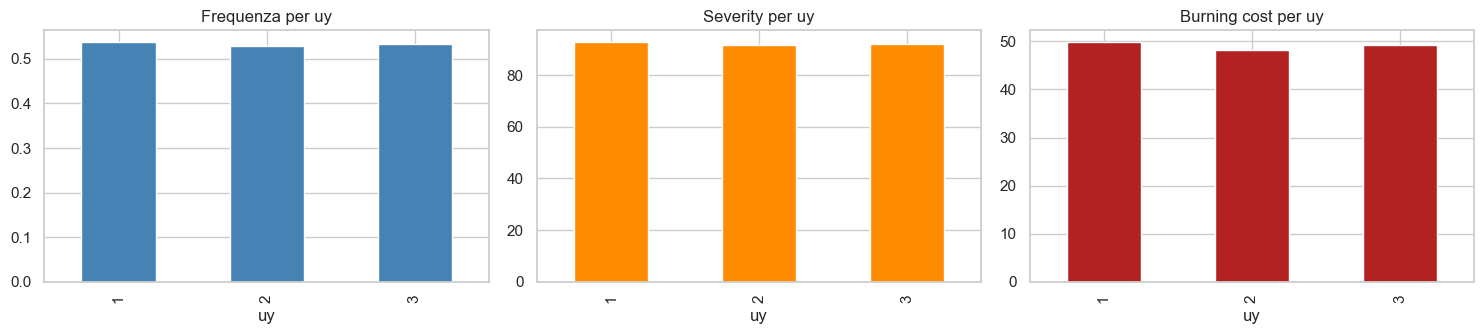

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
stab['frequenza'].plot.bar(ax=ax[0], color='steelblue', title='Frequenza per uy')
stab['severity'].plot.bar(ax=ax[1], color='darkorange', title='Severity per uy')
stab['burning_cost'].plot.bar(ax=ax[2], color='firebrick', title='Burning cost per uy')
for a in ax: a.set_xlabel('uy')
plt.tight_layout(); plt.show()

La frequenza/severity/burning cost vanno confrontati tra anni: una crescita regolare suggerisce
**inflazione/trend** (da tenere presente in validazione, perché il modello addestrato su 2017–2018
potrebbe sotto-stimare il 2019). Eventuali salti anomali andrebbero indagati prima di modellare.

## 7. Definizione dei ruoli delle variabili e salvataggio

Salvo la base modellabile e un dizionario delle feature. Le categoriche restano in forma grezza:
l'encoding (one-hot per i GLM) verrà costruito in NB03, così da poterlo adattare al modello scelto.

In [11]:
ID_COLS = ['id_assicurato', 'id_caponucleo', 'id_nucleo', 'id_azienda', 'uy', 'split']
TARGET_COLS = ['esposizione', 'n_sinistri', 'costo_totale', 'costo_capped',
               'has_claim', 'frequenza', 'severity', 'burning_cost', 'burning_cost_capped']
CAT_FEATURES = ['sesso', 'fascia_eta', 'categoria', 'tipo_assicurato', 'legame_familiare',
                'carico_fiscale', 'settore', 'macroarea', 'regione']
NUM_FEATURES = ['eta', 'composizione_num', 'n_assicurati_nucleo', 'eta_media_nucleo',
                'eta_min_nucleo', 'eta_max_nucleo', 'n_figli_nucleo', 'eta_caponucleo',
                'dimensione_azienda', 'log_dim_azienda']
FLAG_FEATURES = ['presenza_figli', 'presenza_anziani']
FEATURES = CAT_FEATURES + NUM_FEATURES + FLAG_FEATURES

print(f'Predittori totali: {len(FEATURES)}  (cat={len(CAT_FEATURES)}, num={len(NUM_FEATURES)}, flag={len(FLAG_FEATURES)})')
# eta_caponucleo: imputo i pochi mancanti con la mediana del train (no leakage)
med_capo = base.loc[base['split']=='train','eta_caponucleo'].median()
base['eta_caponucleo'] = base['eta_caponucleo'].fillna(med_capo)
print('Missing residui sulle feature:', int(base[FEATURES].isna().sum().sum()))

Predittori totali: 21  (cat=9, num=10, flag=2)
Missing residui sulle feature: 0


In [12]:
keep = ID_COLS + TARGET_COLS + FEATURES
out = base[keep].copy()

path_data = f'{OUT_DIR}/base_modellabile.csv.gz'
out.to_csv(path_data, index=False, compression='gzip')

print('Salvato:')
print(' -', path_data, '->', out.shape)
out.head(3)

Salvato:
 - ../data/processed/base_modellabile.csv.gz -> (78964, 36)


,id_assicurato,id_caponucleo,id_nucleo,id_azienda,uy,split,esposizione,n_sinistri,costo_totale,costo_capped,...,n_assicurati_nucleo,eta_media_nucleo,eta_min_nucleo,eta_max_nucleo,n_figli_nucleo,eta_caponucleo,dimensione_azienda,log_dim_azienda,presenza_figli,presenza_anziani
0,68440933,318440933,P013462,AZ141,1,train,1.0,2.0,200.9,200.9,...,4,24.25,3,43,2,42.0,39,3.688879,1,0
1,68440979,68440979,P008839,AZ032,1,train,1.0,0.0,0.0,0.0,...,1,32.00,32,32,0,32.0,138,4.934474,0,0
2,68440982,68440982,P008788,AZ032,1,train,1.0,1.0,82.1,82.1,...,1,48.00,48,48,0,48.0,138,4.934474,0,0


## 8. Sintesi e prossimi passi

**Cosa abbiamo prodotto**
- Base modellabile **assicurato-anno** pulita (`base_modellabile.csv.gz`), con target e split temporale.
- Pulizia documentata: rimosse 36 righe `esposizione=0`, cap esposizione a 1.0, capping grandi sinistri a p99.5 (stimato su train), orfani esclusi.
- Feature: anagrafiche, struttura del nucleo, dimensione azienda.
- Controllo leakage esplicito: escluse `convenzione` e tutte le grandezze dell'anno corrente derivate dal target.